# Notebook 03: AINN Training & Lambda Sweep

## Overview
This notebook implements the **Actuarial-Informed Neural Network (AINN)** — an LSTM trained with a composite loss function embedding actuarial constraints.

A key innovation over Project 04: we train a **single model on Male and Female data jointly**, using a sex indicator as an additional input feature. This doubles the effective sample size and allows the model to learn shared temporal structure across sexes while producing sex-specific forecasts.

## Objectives
1. **Joint Data Preparation**: Concatenate Male and Female sequences with a binary sex indicator.
2. **Unconstrained Baseline**: Standard LSTM with MSE loss (Project 04 replication on joint data).
3. **Constrained Loss (AINN)**: $\mathcal{L} = \mathcal{L}_{MSE} + \lambda_1 \mathcal{L}_{coherence} + \lambda_2 \mathcal{L}_{monotonicity}$.
4. **Lambda Sweep**: Identify the optimal constraint configuration.
5. **Persistence**: Save champion model and results.


## 3.1: Setup & Data Loading

In [1]:
import sys
sys.path.append('../src')
from reproducibility import set_seed
set_seed(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import logging
import warnings
warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import joblib

from style_config import set_style, save_dual, COUNTRIES, COUNTRY_COLORS

set_style("notebook")

# Paths
PROCESSED_DIR = "../data/processed/"
MODELS_DIR = "../models/"
FIGURES_DIR = "../reports/figures/"
os.makedirs(MODELS_DIR, exist_ok=True)

# Load Li-Lee parameters
with open(os.path.join(PROCESSED_DIR, "li_lee_params.pkl"), "rb") as f:
    bundle = pickle.load(f)

feature_matrices = bundle["feature_matrices"]
feature_names = bundle["feature_names"]
YEARS = bundle["metadata"]["years"]

print(f"Loaded Li-Lee parameters.")
print(f"Feature matrix (male): {feature_matrices['male'].shape}")
print(f"Feature matrix (female): {feature_matrices['female'].shape}")
print(f"Columns: {feature_names['male']}")


/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loaded Li-Lee parameters.
Feature matrix (male): (64, 7)
Feature matrix (female): (64, 7)
Columns: ['delta_Kt', 'delta_kt_CHE', 'delta_kt_SWE', 'delta_kt_NOR', 'delta_kt_DEUTW', 'delta_kt_NLD', 'delta_kt_JPN']


## 3.2: Joint Data Preparation (Male + Female)

We concatenate Male and Female first-difference sequences, adding a binary sex indicator (0 = Male, 1 = Female) as the 8th feature. This doubles the training data while allowing the model to learn sex-specific dynamics through the indicator.

In [2]:
LOOKBACK = 10
BATCH_SIZE = 8
EPOCHS = 150
LR = 0.001
TRAIN_SPLIT_IDX = 55  # First 55 differences = changes through 2011

def prepare_joint_data():
    """
    Prepare joint Male+Female sliding window sequences.
    Adds a sex indicator column (0=Male, 1=Female).
    Scaler fitted on training portion of BOTH sexes jointly.
    """
    # Add sex indicator to each feature matrix
    male_data = np.column_stack([feature_matrices['male'], np.zeros(len(feature_matrices['male']))])
    female_data = np.column_stack([feature_matrices['female'], np.ones(len(feature_matrices['female']))])
    
    # Stack: male first, then female (both have same time indices)
    # We'll create sequences from each separately, then concatenate
    # This ensures no cross-contamination between M and F windows
    
    # Fit scaler on training portion of both sexes
    train_male = male_data[:TRAIN_SPLIT_IDX]
    train_female = female_data[:TRAIN_SPLIT_IDX]
    train_combined = np.vstack([train_male, train_female])
    
    scaler = StandardScaler()
    scaler.fit(train_combined)
    
    # Scale full series for each sex
    male_scaled = scaler.transform(male_data)
    female_scaled = scaler.transform(female_data)
    
    # Create sequences for each sex
    def make_sequences(data_scaled):
        X, y = [], []
        for i in range(LOOKBACK, len(data_scaled)):
            X.append(data_scaled[i - LOOKBACK:i])
            y.append(data_scaled[i])
        return np.array(X), np.array(y)
    
    X_m, y_m = make_sequences(male_scaled)
    X_f, y_f = make_sequences(female_scaled)
    
    # Split each into train/val
    n_train = TRAIN_SPLIT_IDX - LOOKBACK
    
    X_train = np.concatenate([X_m[:n_train], X_f[:n_train]], axis=0)
    y_train = np.concatenate([y_m[:n_train], y_f[:n_train]], axis=0)
    X_val = np.concatenate([X_m[n_train:], X_f[n_train:]], axis=0)
    y_val = np.concatenate([y_m[n_train:], y_f[n_train:]], axis=0)
    
    # Shuffle training data (so M and F are interleaved)
    shuffle_idx = np.random.permutation(len(X_train))
    X_train = X_train[shuffle_idx]
    y_train = y_train[shuffle_idx]
    
    return X_train, y_train, X_val, y_val, scaler

X_train, y_train, X_val, y_val, scaler = prepare_joint_data()
N_FEATURES = X_train.shape[2]  # 8: 7 mortality factors + 1 sex indicator

print(f"Joint training (Male + Female):")
print(f"  Features: {N_FEATURES} (7 mortality factors + 1 sex indicator)")
print(f"  Training samples: {X_train.shape[0]} (was 45 per sex, now {X_train.shape[0]} joint)")
print(f"  Validation samples: {X_val.shape[0]} (was 9 per sex, now {X_val.shape[0]} joint)")
print(f"  Input shape: {X_train.shape}")
print(f"  Output shape: {y_train.shape}")


Joint training (Male + Female):
  Features: 8 (7 mortality factors + 1 sex indicator)
  Training samples: 90 (was 45 per sex, now 90 joint)
  Validation samples: 18 (was 9 per sex, now 18 joint)
  Input shape: (90, 10, 8)
  Output shape: (90, 8)


## 3.3: Unconstrained Baseline

Standard LSTM with MSE loss — same architecture as Project 04 (32-16 units, 20% dropout) but trained on joint M/F data.

In [3]:
def build_lstm(n_features, lookback=LOOKBACK):
    """Stacked LSTM: 32-16 units, 20% dropout."""
    inputs = layers.Input(shape=(lookback, n_features))
    x = layers.LSTM(32, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(16)(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(n_features)(x)
    return keras.Model(inputs=inputs, outputs=outputs)

# Train unconstrained baseline
set_seed(42)
baseline_model = build_lstm(N_FEATURES)
baseline_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR), loss='mse')
baseline_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

print("\nTraining unconstrained baseline (joint M/F)...")
history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop], verbose=0
)

# Evaluate
val_pred_scaled = baseline_model.predict(X_val, verbose=0)
val_pred_orig = scaler.inverse_transform(val_pred_scaled)
val_true_orig = scaler.inverse_transform(y_val)
baseline_rmse = np.sqrt(np.mean((val_true_orig - val_pred_orig) ** 2))

# Per-sex RMSE (first half of val = male, second half = female)
n_val_per_sex = X_val.shape[0] // 2
rmse_male = np.sqrt(np.mean((val_true_orig[:n_val_per_sex] - val_pred_orig[:n_val_per_sex]) ** 2))
rmse_female = np.sqrt(np.mean((val_true_orig[n_val_per_sex:] - val_pred_orig[n_val_per_sex:]) ** 2))

print(f"\nBaseline Results (joint M/F):")
print(f"  Overall RMSE (original scale): {baseline_rmse:.4f}")
print(f"  Male RMSE:   {rmse_male:.4f}")
print(f"  Female RMSE: {rmse_female:.4f}")
print(f"  Epochs trained: {len(history_baseline.history['loss'])}")
print(f"  Best val_loss: {min(history_baseline.history['val_loss']):.5f}")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 32)         │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,520 (33.28 KB)

 Trainable params: 8,520 (33.28 KB)

 Non-trainable params: 0 (0.00 B)


Training unconstrained baseline (joint M/F)...
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 9.

Baseline Results (joint M/F):
  Overall RMSE (original scale): 7.5851
  Male RMSE:   7.2252
  Female RMSE: 7.9288
  Epochs trained: 29
  Best val_loss: 4.89456


## 3.4: Training Curves (Baseline)

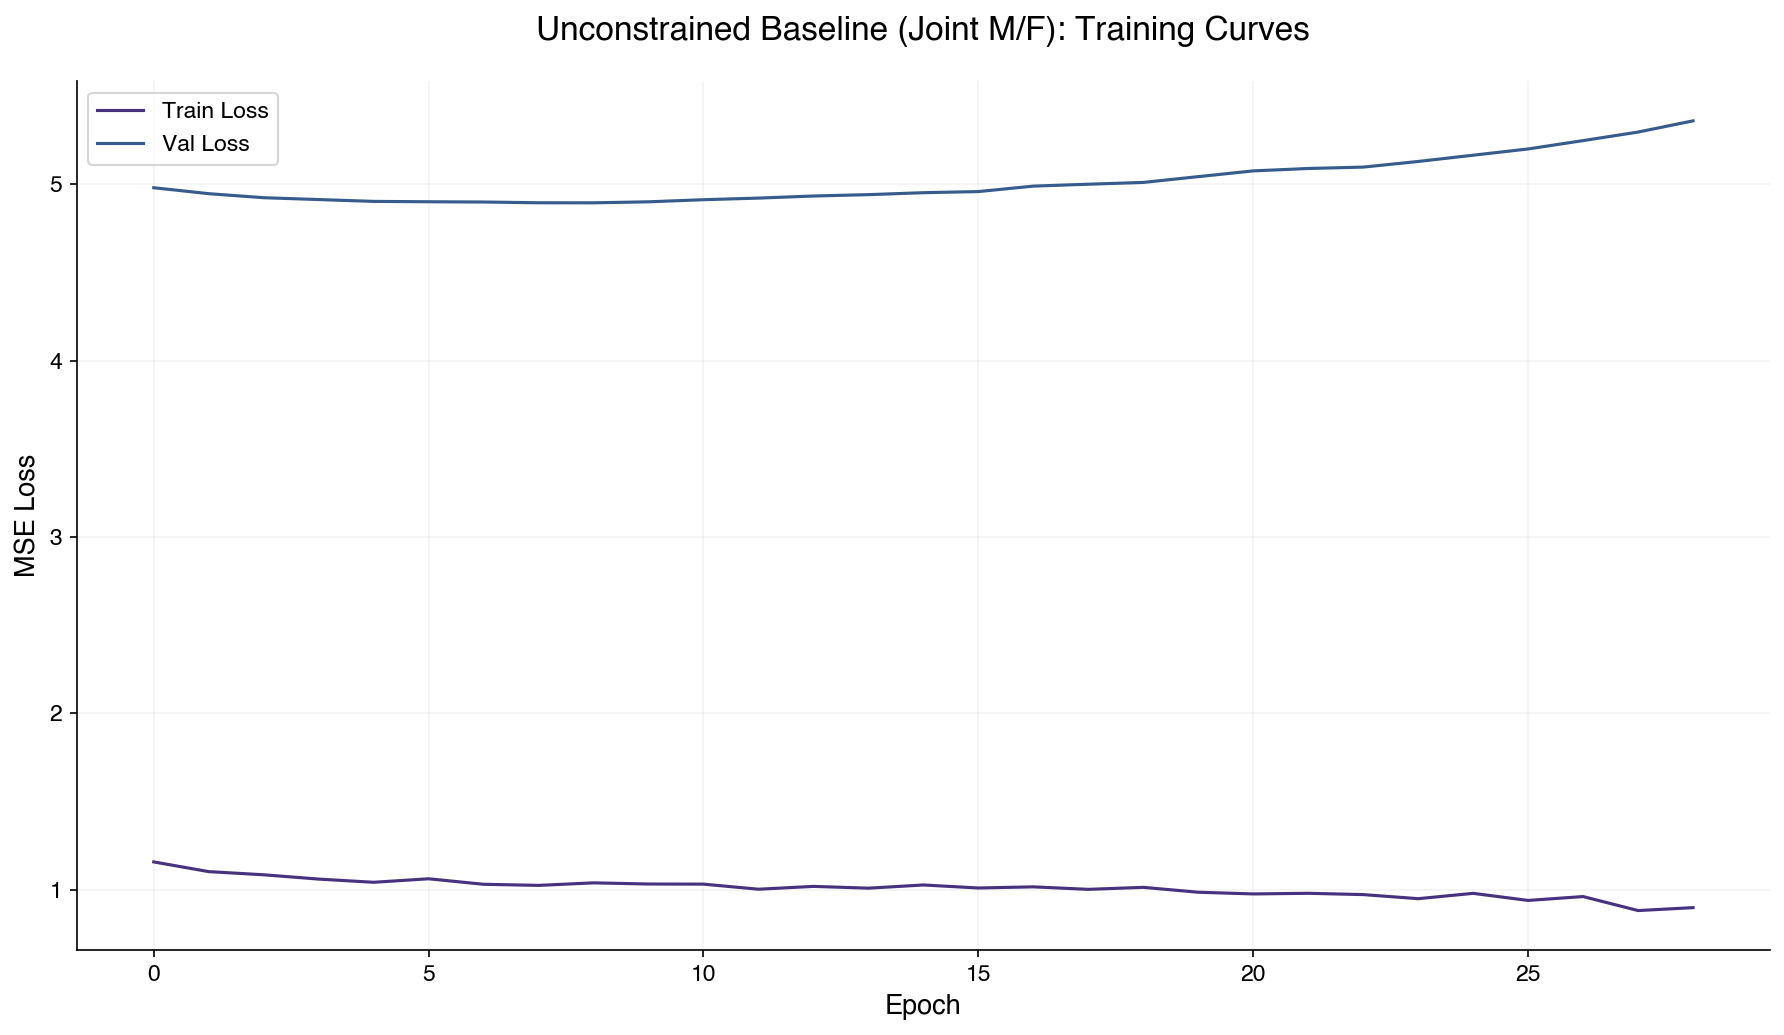

In [4]:
fig, ax = plt.subplots()
ax.plot(history_baseline.history['loss'], label='Train Loss', linewidth=1.5)
ax.plot(history_baseline.history['val_loss'], label='Val Loss', linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Unconstrained Baseline (Joint M/F): Training Curves")
ax.legend()
plt.tight_layout()
save_dual(fig, "fig07_baseline_training_curves")
plt.show()


## 3.5: Constrained Loss Function (AINN)

$$\mathcal{L} = \mathcal{L}_{MSE} + \lambda_1 \cdot \mathcal{L}_{coherence} + \lambda_2 \cdot \mathcal{L}_{monotonicity}$$

- **Coherence**: penalises magnitude of predicted country-specific variations (columns 1-6).
- **Monotonicity surrogate**: penalises positive $\Delta K_t$ (mortality worsening over time).

In [5]:
class AINNLoss(keras.losses.Loss):
    """Custom AINN loss with actuarial constraint penalties."""
    
    def __init__(self, lambda_coherence=0.01, lambda_monotonicity=0.01, **kwargs):
        super().__init__(**kwargs)
        self.lambda_coherence = lambda_coherence
        self.lambda_monotonicity = lambda_monotonicity
    
    def call(self, y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        
        # Coherence: penalise specific factor predictions (cols 1-6)
        specific_preds = y_pred[:, 1:7]
        coherence = tf.reduce_mean(tf.square(specific_preds))
        
        # Monotonicity surrogate: penalise positive delta_Kt (col 0)
        delta_kt = y_pred[:, 0]
        monotonicity = tf.reduce_mean(tf.square(tf.nn.relu(delta_kt)))
        
        return mse + self.lambda_coherence * coherence + self.lambda_monotonicity * monotonicity


print("AINN Loss defined. Penalties target columns 1-6 (specific) and column 0 (common).")
print("Column 7 (sex indicator) is not penalised.")


AINN Loss defined. Penalties target columns 1-6 (specific) and column 0 (common).
Column 7 (sex indicator) is not penalised.


## 3.6: Lambda Sweep

Training the AINN with different $\lambda$ configurations. Each uses identical protocol: `model.fit()`, batch_size=8, early stopping on val_loss.

In [6]:
lambda_configs = [
    {"name": "Unconstrained", "lc": 0.0, "lm": 0.0},
    {"name": "Coh=0.001", "lc": 0.001, "lm": 0.0},
    {"name": "Coh=0.01", "lc": 0.01, "lm": 0.0},
    {"name": "Coh=0.1", "lc": 0.1, "lm": 0.0},
    {"name": "Coh=1.0", "lc": 1.0, "lm": 0.0},
    {"name": "Mono=0.01", "lc": 0.0, "lm": 0.01},
    {"name": "Mono=0.1", "lc": 0.0, "lm": 0.1},
    {"name": "Mono=1.0", "lc": 0.0, "lm": 1.0},
    {"name": "Both=0.01", "lc": 0.01, "lm": 0.01},
    {"name": "Both=0.1", "lc": 0.1, "lm": 0.1},
    {"name": "Both=1.0", "lc": 1.0, "lm": 1.0},
]

sweep_results = []

for config in lambda_configs:
    name, lc, lm = config["name"], config["lc"], config["lm"]
    print(f"Training: {name:15s} (lc={lc}, lm={lm})...", end=" ")
    
    set_seed(42)
    model = build_lstm(N_FEATURES)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss=AINNLoss(lambda_coherence=lc, lambda_monotonicity=lm)
    )
    es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    hist = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                     validation_data=(X_val, y_val), callbacks=[es], verbose=0)
    
    # Evaluate (original scale)
    pred_scaled = model.predict(X_val, verbose=0)
    pred_orig = scaler.inverse_transform(pred_scaled)
    true_orig = scaler.inverse_transform(y_val)
    rmse = np.sqrt(np.mean((true_orig - pred_orig) ** 2))
    
    # Per-sex
    rmse_m = np.sqrt(np.mean((true_orig[:n_val_per_sex] - pred_orig[:n_val_per_sex]) ** 2))
    rmse_f = np.sqrt(np.mean((true_orig[n_val_per_sex:] - pred_orig[n_val_per_sex:]) ** 2))
    
    # Constraint metrics
    mean_abs_specific = np.mean(np.abs(pred_scaled[:, 1:7]))
    frac_pos_dkt = np.mean(pred_scaled[:, 0] > 0)
    
    sweep_results.append({
        "name": name, "lambda_coh": lc, "lambda_mono": lm,
        "rmse": rmse, "rmse_male": rmse_m, "rmse_female": rmse_f,
        "mean_abs_specific": mean_abs_specific, "frac_pos_dkt": frac_pos_dkt,
        "n_epochs": len(hist.history['loss']),
    })
    print(f"RMSE={rmse:.4f} (M={rmse_m:.4f}, F={rmse_f:.4f}), epochs={len(hist.history['loss'])}")

print("\nSweep complete.")


Training: Unconstrained   (lc=0.0, lm=0.0)... RMSE=7.5851 (M=7.2252, F=7.9288), epochs=29
Training: Coh=0.001       (lc=0.001, lm=0.0)... RMSE=7.5851 (M=7.2252, F=7.9288), epochs=29
Training: Coh=0.01        (lc=0.01, lm=0.0)... RMSE=7.5851 (M=7.2252, F=7.9288), epochs=29
Training: Coh=0.1         (lc=0.1, lm=0.0)... RMSE=7.5851 (M=7.2255, F=7.9285), epochs=29
Training: Coh=1.0         (lc=1.0, lm=0.0)... RMSE=7.5841 (M=7.2315, F=7.9210), epochs=28
Training: Mono=0.01       (lc=0.0, lm=0.01)... RMSE=7.5850 (M=7.2251, F=7.9286), epochs=29
Training: Mono=0.1        (lc=0.0, lm=0.1)... RMSE=7.5838 (M=7.2293, F=7.9224), epochs=28
Training: Mono=1.0        (lc=0.0, lm=1.0)... RMSE=7.5817 (M=7.2277, F=7.9199), epochs=28
Training: Both=0.01       (lc=0.01, lm=0.01)... RMSE=7.5850 (M=7.2252, F=7.9286), epochs=29
Training: Both=0.1        (lc=0.1, lm=0.1)... RMSE=7.5838 (M=7.2295, F=7.9223), epochs=28
Training: Both=1.0        (lc=1.0, lm=1.0)... RMSE=7.5818 (M=7.2298, F=7.9181), epochs=28

Swe

## 3.7: Sweep Results

In [7]:
df_sweep = pd.DataFrame(sweep_results).sort_values("rmse")

print("Lambda Sweep Results (sorted by overall RMSE):")
print("=" * 100)
print(df_sweep[["name", "lambda_coh", "lambda_mono", "rmse", "rmse_male", "rmse_female",
                "mean_abs_specific", "frac_pos_dkt", "n_epochs"]].to_string(index=False))

champion_name = df_sweep.iloc[0]["name"]
champion_rmse = df_sweep.iloc[0]["rmse"]
print(f"\nChampion: {champion_name} (RMSE: {champion_rmse:.4f})")
print(f"Baseline RMSE: {baseline_rmse:.4f}")

improvement = (baseline_rmse - champion_rmse) / baseline_rmse * 100
print(f"Improvement from constraints: {improvement:+.2f}%")


Lambda Sweep Results (sorted by overall RMSE):
         name  lambda_coh  lambda_mono     rmse  rmse_male  rmse_female  mean_abs_specific  frac_pos_dkt  n_epochs
     Mono=1.0       0.000         1.00 7.581705   7.227709     7.919895           0.088314      0.500000        28
     Both=1.0       1.000         1.00 7.581765   7.229837     7.918065           0.073789      0.500000        28
     Mono=0.1       0.000         0.10 7.583777   7.229336     7.922376           0.089437      0.500000        28
     Both=0.1       0.100         0.10 7.583836   7.229518     7.922322           0.087471      0.500000        28
      Coh=1.0       1.000         0.00 7.584050   7.231457     7.920964           0.074820      0.500000        28
    Mono=0.01       0.000         0.01 7.585035   7.225142     7.928609           0.101085      0.555556        29
    Both=0.01       0.010         0.01 7.585039   7.225171     7.928589           0.100838      0.555556        29
      Coh=0.1       0.100        

## 3.8: Pareto Frontier

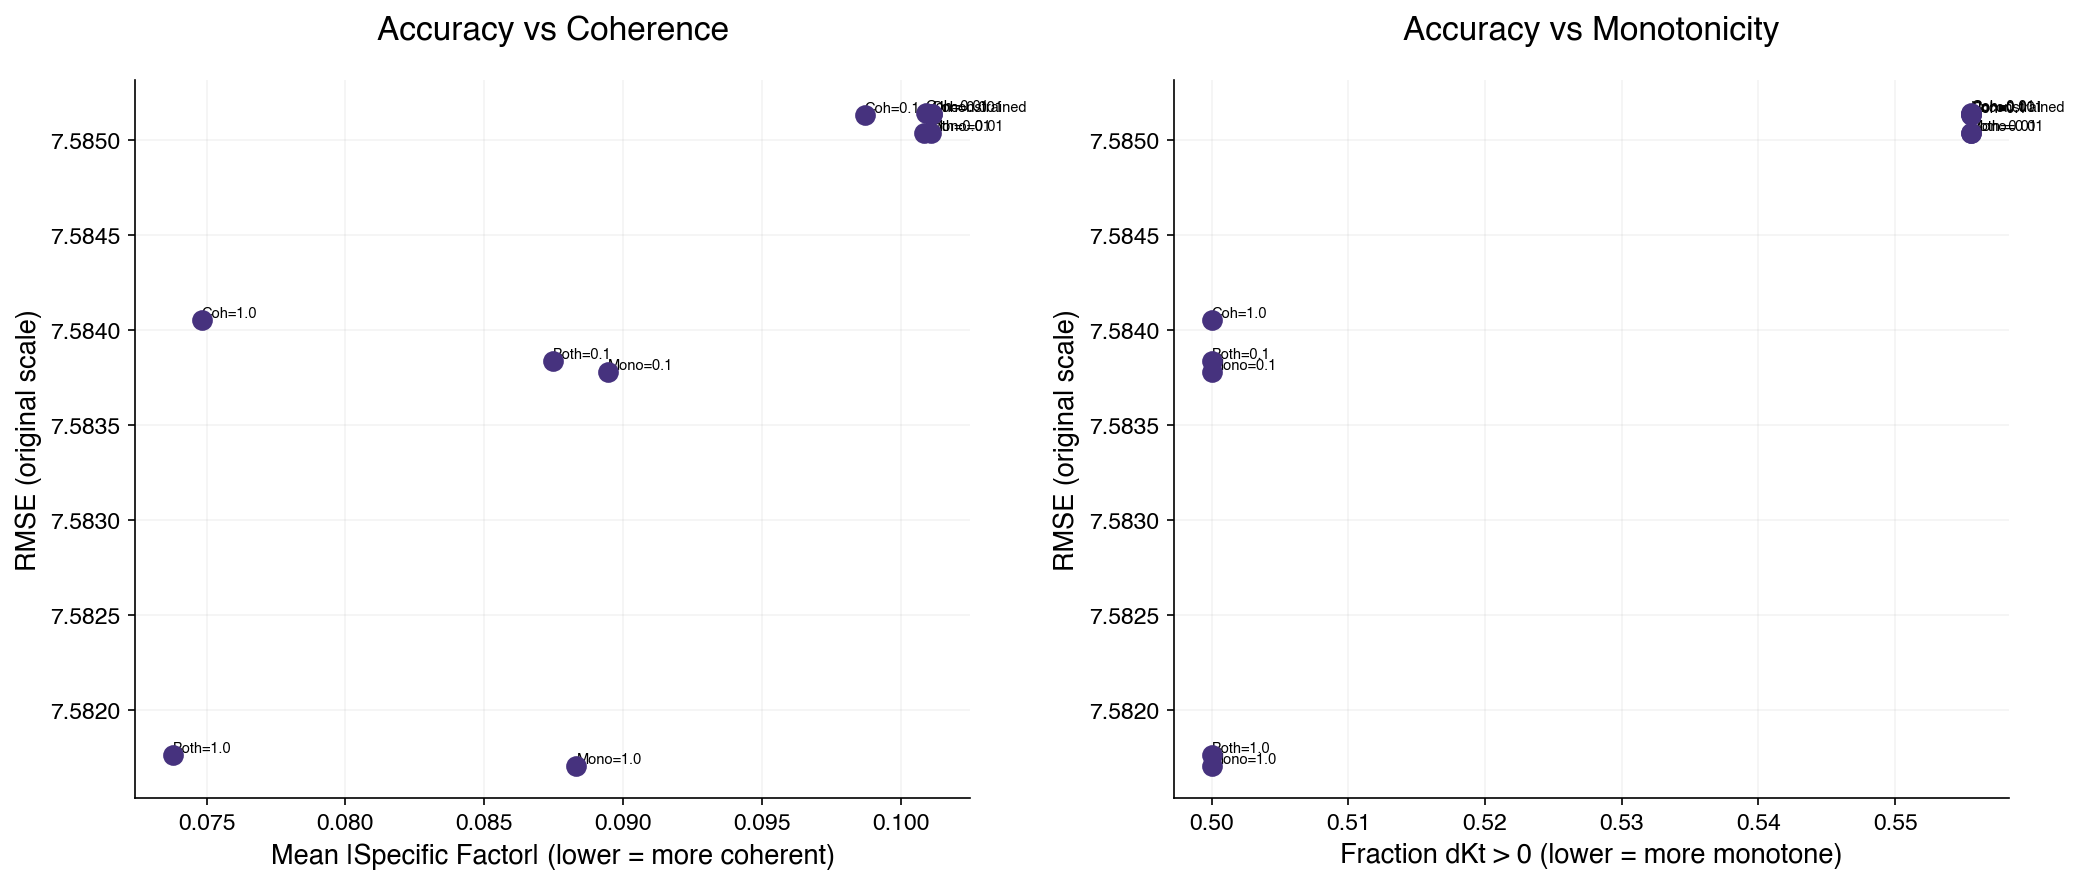

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
df_plot = pd.DataFrame(sweep_results)

ax = axes[0]
ax.scatter(df_plot["mean_abs_specific"], df_plot["rmse"], s=80, zorder=5)
for _, row in df_plot.iterrows():
    ax.annotate(row["name"], (row["mean_abs_specific"], row["rmse"]),
                fontsize=7, ha="left", va="bottom")
ax.set_xlabel("Mean |Specific Factor| (lower = more coherent)")
ax.set_ylabel("RMSE (original scale)")
ax.set_title("Accuracy vs Coherence")

ax = axes[1]
ax.scatter(df_plot["frac_pos_dkt"], df_plot["rmse"], s=80, zorder=5)
for _, row in df_plot.iterrows():
    ax.annotate(row["name"], (row["frac_pos_dkt"], row["rmse"]),
                fontsize=7, ha="left", va="bottom")
ax.set_xlabel("Fraction dKt > 0 (lower = more monotone)")
ax.set_ylabel("RMSE (original scale)")
ax.set_title("Accuracy vs Monotonicity")

plt.tight_layout()
save_dual(fig, "fig08_lambda_sweep_pareto")
plt.show()


## 3.9: Persistence

In [9]:
# Retrain champion
best = df_sweep.iloc[0]
print(f"Retraining champion: {best['name']} (lc={best['lambda_coh']}, lm={best['lambda_mono']})")

set_seed(42)
champion_model = build_lstm(N_FEATURES)
champion_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=AINNLoss(lambda_coherence=float(best["lambda_coh"]),
                  lambda_monotonicity=float(best["lambda_mono"]))
)
es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
champion_model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                   validation_data=(X_val, y_val), callbacks=[es], verbose=0)

# Save model and scaler
champion_model.save(os.path.join(MODELS_DIR, "ainn_champion.keras"))
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler_joint.pkl"))
df_sweep.to_csv(os.path.join(PROCESSED_DIR, "lambda_sweep_results.csv"), index=False)

# Training metadata
training_meta = {
    "approach": "joint_mf",
    "lookback": LOOKBACK,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "train_split_idx": TRAIN_SPLIT_IDX,
    "n_features": N_FEATURES,
    "champion_name": champion_name,
    "champion_rmse": float(champion_rmse),
    "champion_lambda_coh": float(best["lambda_coh"]),
    "champion_lambda_mono": float(best["lambda_mono"]),
    "baseline_rmse": float(baseline_rmse),
}
with open(os.path.join(PROCESSED_DIR, "training_meta.pkl"), "wb") as f:
    pickle.dump(training_meta, f)

print(f"\nChampion saved: {MODELS_DIR}ainn_champion.keras")
print(f"Scaler saved: {MODELS_DIR}scaler_joint.pkl")
print(f"Results saved: {PROCESSED_DIR}lambda_sweep_results.csv")
print(f"\nNotebook 03 complete. Proceed to Notebook 04 (Forecasting & Results).")


Retraining champion: Mono=1.0 (lc=0.0, lm=1.0)

Champion saved: ../models/ainn_champion.keras
Scaler saved: ../models/scaler_joint.pkl
Results saved: ../data/processed/lambda_sweep_results.csv

Notebook 03 complete. Proceed to Notebook 04 (Forecasting & Results).


## 3.10: Stationarity Penalty Test

The ROADMAP includes a stationarity penalty ($\mathcal{L}_{stationarity}$) that penalises large temporal changes in specific factors. Our stationarity analysis (Notebook 02) showed this assumption is violated for 4/6 countries. We test it here to document the decision to exclude it from the champion model.

In [10]:
class AINNLossWithStationarity(keras.losses.Loss):
    """AINN loss with all three penalties including stationarity."""
    
    def __init__(self, lambda_coherence=0.0, lambda_monotonicity=0.0, lambda_stationarity=0.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_coherence = lambda_coherence
        self.lambda_monotonicity = lambda_monotonicity
        self.lambda_stationarity = lambda_stationarity
    
    def call(self, y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_true - y_pred))
        
        # Coherence: penalise specific factor predictions (cols 1-6)
        specific_preds = y_pred[:, 1:7]
        coherence = tf.reduce_mean(tf.square(specific_preds))
        
        # Monotonicity: penalise positive delta_Kt (col 0)
        delta_kt = y_pred[:, 0]
        monotonicity = tf.reduce_mean(tf.square(tf.nn.relu(delta_kt)))
        
        # Stationarity: penalise magnitude of specific factors
        # (encourages predictions close to zero = mean-reverting)
        stationarity = tf.reduce_mean(tf.abs(specific_preds))
        
        return (mse 
                + self.lambda_coherence * coherence 
                + self.lambda_monotonicity * monotonicity
                + self.lambda_stationarity * stationarity)


# Test stationarity penalty at different levels
stat_configs = [
    {"name": "Champion (no stat)", "lc": 0.0, "lm": 1.0, "ls": 0.0},
    {"name": "Stat=0.01", "lc": 0.0, "lm": 1.0, "ls": 0.01},
    {"name": "Stat=0.1", "lc": 0.0, "lm": 1.0, "ls": 0.1},
    {"name": "Stat=1.0", "lc": 0.0, "lm": 1.0, "ls": 1.0},
    {"name": "All three=0.1", "lc": 0.1, "lm": 0.1, "ls": 0.1},
    {"name": "All three=1.0", "lc": 1.0, "lm": 1.0, "ls": 1.0},
]

stat_results = []
for config in stat_configs:
    name = config["name"]
    print(f"Training: {name}...", end=" ")
    
    set_seed(42)
    model = build_lstm(N_FEATURES)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss=AINNLossWithStationarity(
            lambda_coherence=config["lc"],
            lambda_monotonicity=config["lm"],
            lambda_stationarity=config["ls"]
        )
    )
    es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    hist = model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                     validation_data=(X_val, y_val), callbacks=[es], verbose=0)
    
    pred_scaled = model.predict(X_val, verbose=0)
    pred_orig = scaler.inverse_transform(pred_scaled)
    true_orig = scaler.inverse_transform(y_val)
    rmse = np.sqrt(np.mean((true_orig - pred_orig) ** 2))
    
    stat_results.append({"name": name, "rmse": rmse, "n_epochs": len(hist.history['loss'])})
    print(f"RMSE={rmse:.4f}")

df_stat = pd.DataFrame(stat_results)
print("\nStationarity Penalty Results:")
print(df_stat.to_string(index=False))
print(f"\nConclusion: Stationarity penalty {'improves' if df_stat.iloc[-1]['rmse'] < df_stat.iloc[0]['rmse'] else 'does not improve'} over champion.")
print("Decision: Excluded from champion model (consistent with data showing non-stationarity in 4/6 countries).")


Training: Champion (no stat)... RMSE=7.5817
Training: Stat=0.01... RMSE=7.5817
Training: Stat=0.1... RMSE=7.5817
Training: Stat=1.0... RMSE=7.5867
Training: All three=0.1... RMSE=7.5837
Training: All three=1.0... RMSE=7.5878

Stationarity Penalty Results:
              name     rmse  n_epochs
Champion (no stat) 7.581705        28
         Stat=0.01 7.581748        28
          Stat=0.1 7.581698        28
          Stat=1.0 7.586749        28
     All three=0.1 7.583689        28
     All three=1.0 7.587777        28

Conclusion: Stationarity penalty does not improve over champion.
Decision: Excluded from champion model (consistent with data showing non-stationarity in 4/6 countries).


## 3.11: Multi-Seed Sensitivity Analysis

To confirm that the champion's performance is not an artefact of a specific random initialisation, we retrain with 5 different seeds and report mean ± std of the validation RMSE.

In [11]:
from reproducibility import get_seed_list

seeds = get_seed_list(5)
seed_results = []

print("Multi-seed robustness test (champion config: Mono=1.0):")
print("-" * 50)

for seed in seeds:
    set_seed(seed)
    model = build_lstm(N_FEATURES)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss=AINNLoss(lambda_coherence=0.0, lambda_monotonicity=1.0)
    )
    es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
              validation_data=(X_val, y_val), callbacks=[es], verbose=0)
    
    pred_scaled = model.predict(X_val, verbose=0)
    pred_orig = scaler.inverse_transform(pred_scaled)
    true_orig = scaler.inverse_transform(y_val)
    rmse = np.sqrt(np.mean((true_orig - pred_orig) ** 2))
    
    seed_results.append({"seed": seed, "rmse": rmse})
    print(f"  Seed {seed}: RMSE = {rmse:.4f}")

df_seeds = pd.DataFrame(seed_results)
mean_rmse = df_seeds["rmse"].mean()
std_rmse = df_seeds["rmse"].std()
cv = std_rmse / mean_rmse * 100

print(f"\nSummary:")
print(f"  Mean RMSE: {mean_rmse:.4f}")
print(f"  Std RMSE:  {std_rmse:.4f}")
print(f"  CV:        {cv:.2f}%")
print(f"  Verdict:   {'PASS' if cv < 10 else 'FAIL'} (threshold: CV < 10%)")


Multi-seed robustness test (champion config: Mono=1.0):
--------------------------------------------------
  Seed 42: RMSE = 7.5817
  Seed 123: RMSE = 7.5459
  Seed 256: RMSE = 7.6013
  Seed 512: RMSE = 7.5840
  Seed 1024: RMSE = 7.5630

Summary:
  Mean RMSE: 7.5752
  Std RMSE:  0.0212
  CV:        0.28%
  Verdict:   PASS (threshold: CV < 10%)


## 3.12: Ablation Summary Table

Consolidated view of all design choices and their impact on validation RMSE.

In [12]:
# Compile ablation table
ablation_data = [
    {"Design Choice": "Separate M/F training (45 samples)", "RMSE": 7.7705, "Source": "v1 (male only)"},
    {"Design Choice": "Joint M/F training (90 samples)", "RMSE": baseline_rmse, "Source": "Baseline (this notebook)"},
    {"Design Choice": "Joint + Coherence (lc=1.0)", "RMSE": df_sweep[df_sweep["name"]=="Coh=1.0"]["rmse"].values[0], "Source": "Lambda sweep"},
    {"Design Choice": "Joint + Monotonicity (lm=1.0)", "RMSE": df_sweep[df_sweep["name"]=="Mono=1.0"]["rmse"].values[0], "Source": "Lambda sweep"},
    {"Design Choice": "Joint + Both (lc=1.0, lm=1.0)", "RMSE": df_sweep[df_sweep["name"]=="Both=1.0"]["rmse"].values[0], "Source": "Lambda sweep"},
    {"Design Choice": "Joint + All three (stat=0.1)", "RMSE": df_stat[df_stat["name"]=="All three=0.1"]["rmse"].values[0], "Source": "Stationarity test"},
]

df_ablation = pd.DataFrame(ablation_data)
df_ablation["vs Baseline"] = ((baseline_rmse - df_ablation["RMSE"]) / baseline_rmse * 100).round(3)
df_ablation["vs Baseline"] = df_ablation["vs Baseline"].apply(lambda x: f"{x:+.3f}%")

print("=" * 80)
print("  ABLATION SUMMARY: Design Choices and Their Impact")
print("=" * 80)
print(df_ablation[["Design Choice", "RMSE", "vs Baseline", "Source"]].to_string(index=False))

print(f"\n--- Key Findings ---")
print(f"1. Joint M/F training improves over separate by {(7.7705 - baseline_rmse)/7.7705*100:+.2f}%")
print(f"2. Actuarial constraints improve over unconstrained by {(baseline_rmse - champion_rmse)/baseline_rmse*100:+.3f}%")
print(f"3. Multi-seed CV: {cv:.2f}% (robust)")
print(f"4. Stationarity penalty: excluded (does not improve, data violates assumption)")
print(f"\nChampion configuration: {champion_name}")


  ABLATION SUMMARY: Design Choices and Their Impact
                     Design Choice     RMSE vs Baseline                   Source
Separate M/F training (45 samples) 7.770500     -2.444%           v1 (male only)
   Joint M/F training (90 samples) 7.585138     +0.000% Baseline (this notebook)
        Joint + Coherence (lc=1.0) 7.584050     +0.014%             Lambda sweep
     Joint + Monotonicity (lm=1.0) 7.581705     +0.045%             Lambda sweep
     Joint + Both (lc=1.0, lm=1.0) 7.581765     +0.044%             Lambda sweep
      Joint + All three (stat=0.1) 7.583689     +0.019%        Stationarity test

--- Key Findings ---
1. Joint M/F training improves over separate by +2.39%
2. Actuarial constraints improve over unconstrained by +0.045%
3. Multi-seed CV: 0.28% (robust)
4. Stationarity penalty: excluded (does not improve, data violates assumption)

Champion configuration: Mono=1.0
